# CFM56-5B — Off-Design Analízis
Három repülési fázis összehasonlítása: **Felszállás · Emelkedés · Cruise**

In [ ]:
import sys
sys.path.insert(0, '..')
from engine import run_off_design
import pandas as pd

phases = [
    {'flight_phase': 'takeoff', 'altitude_ft': 0,      'mach': 0.25},
    {'flight_phase': 'climb',   'altitude_ft': 15000,  'mach': 0.50},
    {'flight_phase': 'cruise',  'altitude_ft': 35000,  'mach': 0.78},
]
results = run_off_design(phases)
for r in results:
    r.summary()
    print()

## Összefoglaló táblázat

In [ ]:
summary = pd.DataFrame([{
    'Fázis':       r.flight_phase,
    'Magasság ft': r.altitude_ft,
    'Mach':        r.mach,
    'Tolóerő kN':  round(r.thrust_kN, 1),
    'SFC':         round(r.sfc, 5),
    'OPR':         round(r.opr, 2),
    'BPR':         round(r.bpr, 2),
    'W kg/s':      round(r.mass_flow, 1),
    'N1 %':        round(r.N1, 1),
    'N2 %':        round(r.N2, 1),
} for r in results])
summary

## T-s diagram

Mentve: off_design_ts.png


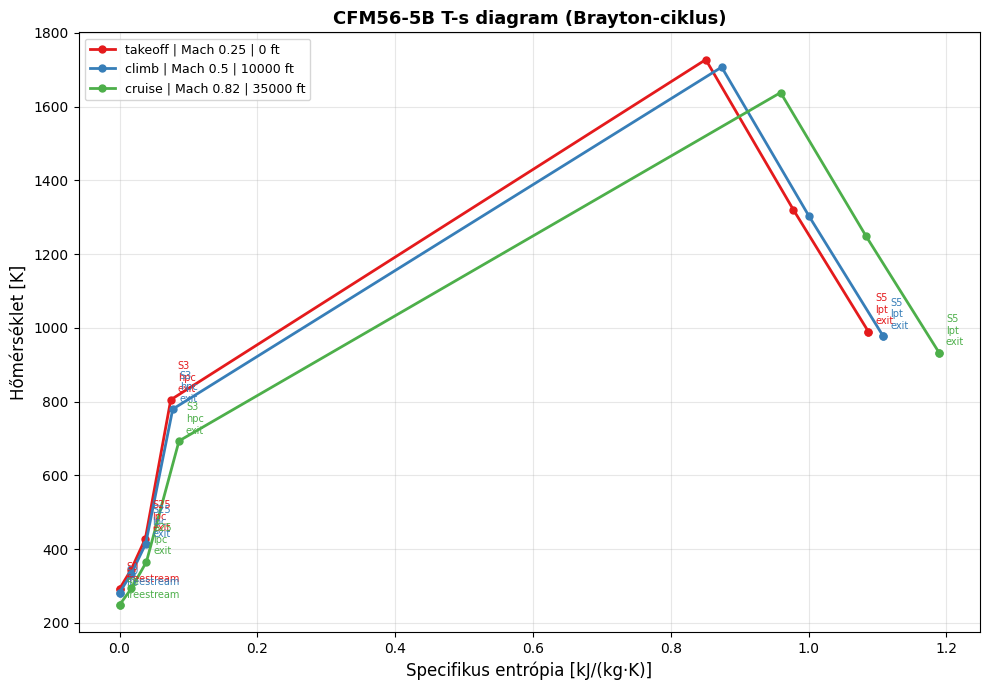

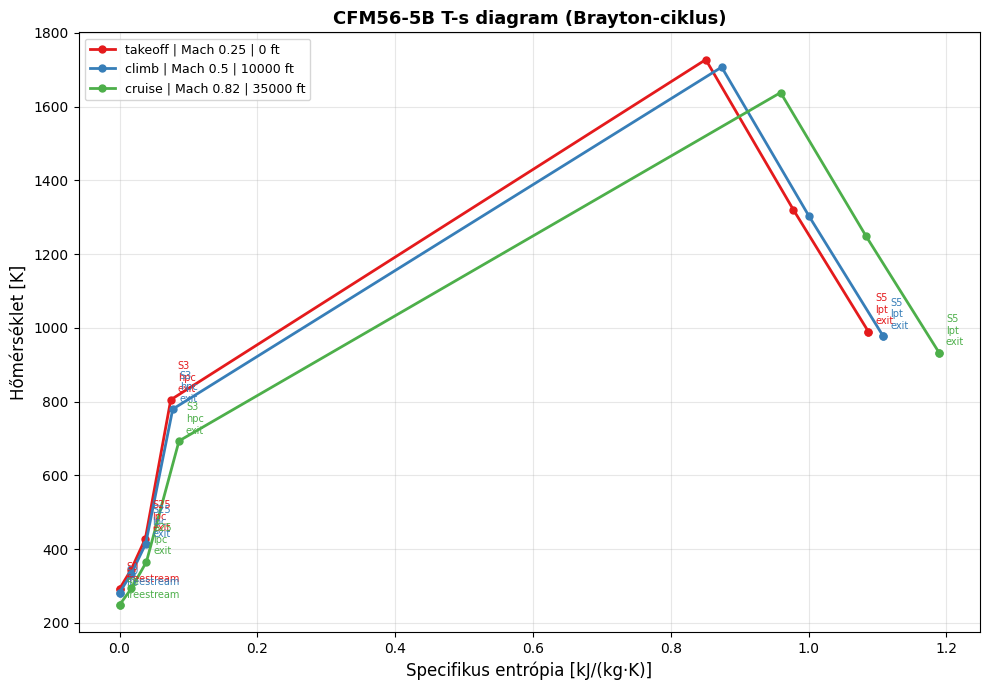

In [3]:
import matplotlib.pyplot as plt
from visualization import plot_ts_diagram

fig = plot_ts_diagram(results)
fig.savefig('off_design_ts.png', dpi=150, bbox_inches='tight')
print('Mentve: off_design_ts.png')
fig